In [14]:
!pip install opencv-python-headless --quiet

In [9]:
uploaded = files.upload()

Saving images.jpg to images (1).jpg
Saving photos-for-whatsapp-profile-pic-photos-for-whatsapp-dp.webp to photos-for-whatsapp-profile-pic-photos-for-whatsapp-dp.webp


In [15]:
import cv2
import numpy as np
from google.colab import files
from matplotlib import pyplot as plt

In [16]:
print("Upload an image to detect red objects...")
uploaded = files.upload()

Upload an image to detect red objects...


Saving sample2.jpg to sample2.jpg


In [17]:
input_image_path = list(uploaded.keys())[0]

In [20]:
# Step 4: Read the image
image = cv2.imread(input_image_path)

if image is None:
    print("Error: Couldn't read the image.")
else:
    # Step 5: Convert BGR image to HSV color space
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

In [21]:
# Step 6: Define range for red color in HSV
# Red appears in two ranges in HSV (around 0° and 180°)
lower_red1 = np.array([0, 120, 70])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 120, 70])
upper_red2 = np.array([180, 255, 255])

In [22]:
# Step 7: Create masks for red color
mask1 = cv2.inRange(hsv_image, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv_image, lower_red2, upper_red2)
red_mask = mask1 + mask2

In [23]:
# Step 8: Apply the mask to the original image
red_detected = cv2.bitwise_and(image, image, mask=red_mask)

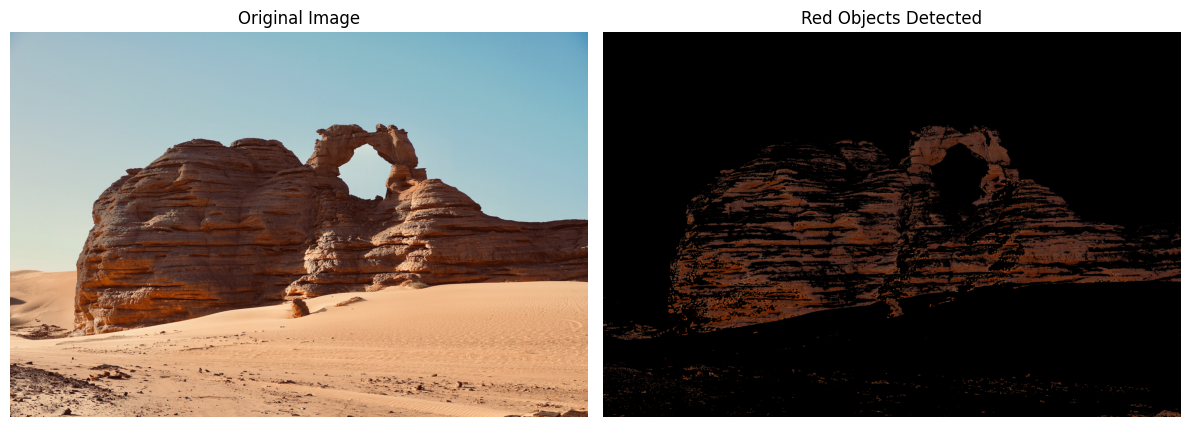

In [24]:
# Step 9: Show original and result side by side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(red_detected, cv2.COLOR_BGR2RGB))
plt.title("Red Objects Detected")
plt.axis('off')
plt.tight_layout()
plt.show()